In [35]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["font.sans-serif"] = ["SimHei", "Microsoft YaHei", "WenQuanYi Micro Hei", "sans-serif"]
plt.rcParams["axes.unicode_minus"] = False

from config import (
    TRAIN_FILE, TFIDF_MODEL_FILE, FIGURES_DIR, MODELS_DIR,
    KMEANS_K_RANGE, KMEANS_N_INIT, KMEANS_MAX_ITER, KMEANS_RANDOM_STATE,
    KMEANS_MODEL_FILE, CLUSTER_LABELS_FILE,
)

# 加载训练集
train_df = pd.read_csv(str(TRAIN_FILE), encoding="utf-8-sig")
train_texts = train_df["processed_text"].fillna("").astype(str)

# 加载已训练的 TF-IDF vectorizer 并 transform
vectorizer = joblib.load(str(TFIDF_MODEL_FILE))
tfidf_matrix = vectorizer.transform(train_texts)
feature_names = vectorizer.get_feature_names_out()

print(f"训练集: {len(train_df)} 条")
print(f"TF-IDF 矩阵: {tfidf_matrix.shape}")

训练集: 6181 条
TF-IDF 矩阵: (6181, 5000)


计算各 K 值的 WCSS...
  K= 2  WCSS=5918.19
  K= 3  WCSS=5900.67
  K= 4  WCSS=5885.85
  K= 5  WCSS=5870.09
  K= 6  WCSS=5863.77
  K= 7  WCSS=5854.86
  K= 8  WCSS=5844.47
  K= 9  WCSS=5831.51
  K=10  WCSS=5817.48
  K=11  WCSS=5813.74
  K=12  WCSS=5803.38
  K=13  WCSS=5787.60
  K=14  WCSS=5781.91
  K=15  WCSS=5775.97
  K=16  WCSS=5758.97
  K=17  WCSS=5755.40
  K=18  WCSS=5745.09
  K=19  WCSS=5739.34
  K=20  WCSS=5729.92

肘部法则图已保存: D:\code-hub\ml-service\outputs\figures\elbow_method.png


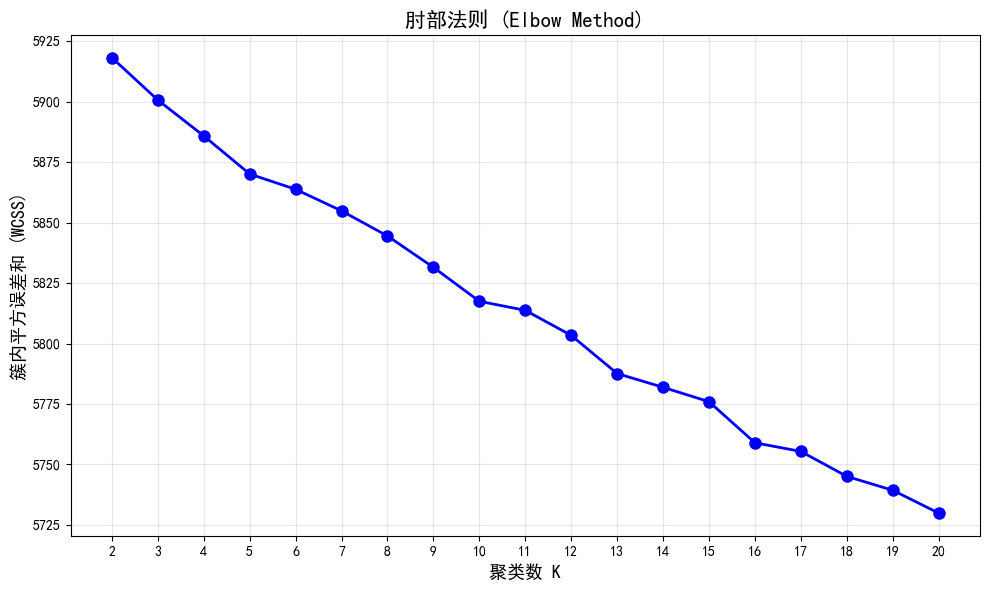

In [36]:
from sklearn.cluster import KMeans

k_range = list(KMEANS_K_RANGE)
wcss_list = []  # Within-Cluster Sum of Squares

print("计算各 K 值的 WCSS...")
for k in k_range:
    km = KMeans(
        n_clusters=k,
        init="k-means++",
        n_init=KMEANS_N_INIT,
        max_iter=KMEANS_MAX_ITER,
        random_state=KMEANS_RANDOM_STATE,
    )
    km.fit(tfidf_matrix)
    wcss_list.append(km.inertia_)
    print(f"  K={k:2d}  WCSS={km.inertia_:.2f}")

# 绘制肘部法则曲线
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(k_range, wcss_list, "bo-", linewidth=2, markersize=8)
ax.set_xlabel("聚类数 K", fontsize=13)
ax.set_ylabel("簇内平方误差和 (WCSS)", fontsize=13)
ax.set_title("肘部法则 (Elbow Method)", fontsize=15)
ax.set_xticks(k_range)
ax.grid(True, alpha=0.3)
plt.tight_layout()

os.makedirs(str(FIGURES_DIR), exist_ok=True)
fig.savefig(str(FIGURES_DIR / "elbow_method.png"), dpi=200)
print(f"\n肘部法则图已保存: {FIGURES_DIR / 'elbow_method.png'}")
plt.show()

计算各 K 值的聚类评估指标...
  K= 2  Silhouette=0.0141  CH=45.2  DB=4.1350
  K= 3  Silhouette=0.0143  CH=31.8  DB=5.7660
  K= 4  Silhouette=0.0134  CH=26.4  DB=9.6808
  K= 5  Silhouette=0.0146  CH=24.0  DB=8.5819
  K= 6  Silhouette=0.0142  CH=20.6  DB=8.8485
  K= 7  Silhouette=0.0141  CH=18.7  DB=8.9369
  K= 8  Silhouette=0.0153  CH=17.7  DB=7.3294
  K= 9  Silhouette=0.0160  CH=17.2  DB=7.3101
  K=10  Silhouette=0.0157  CH=17.0  DB=7.7068
  K=11  Silhouette=0.0165  CH=15.7  DB=7.4866
  K=12  Silhouette=0.0169  CH=15.3  DB=7.4462
  K=13  Silhouette=0.0180  CH=15.4  DB=6.8869
  K=14  Silhouette=0.0182  CH=14.7  DB=6.8896
  K=15  Silhouette=0.0184  CH=14.1  DB=6.8532
  K=16  Silhouette=0.0181  CH=14.5  DB=6.9959
  K=17  Silhouette=0.0195  CH=13.8  DB=6.5559
  K=18  Silhouette=0.0197  CH=13.7  DB=6.3959
  K=19  Silhouette=0.0200  CH=13.2  DB=6.3741
  K=20  Silhouette=0.0198  CH=13.1  DB=6.5348

聚类指标图已保存: D:\code-hub\ml-service\outputs\figures\clustering_metrics.png


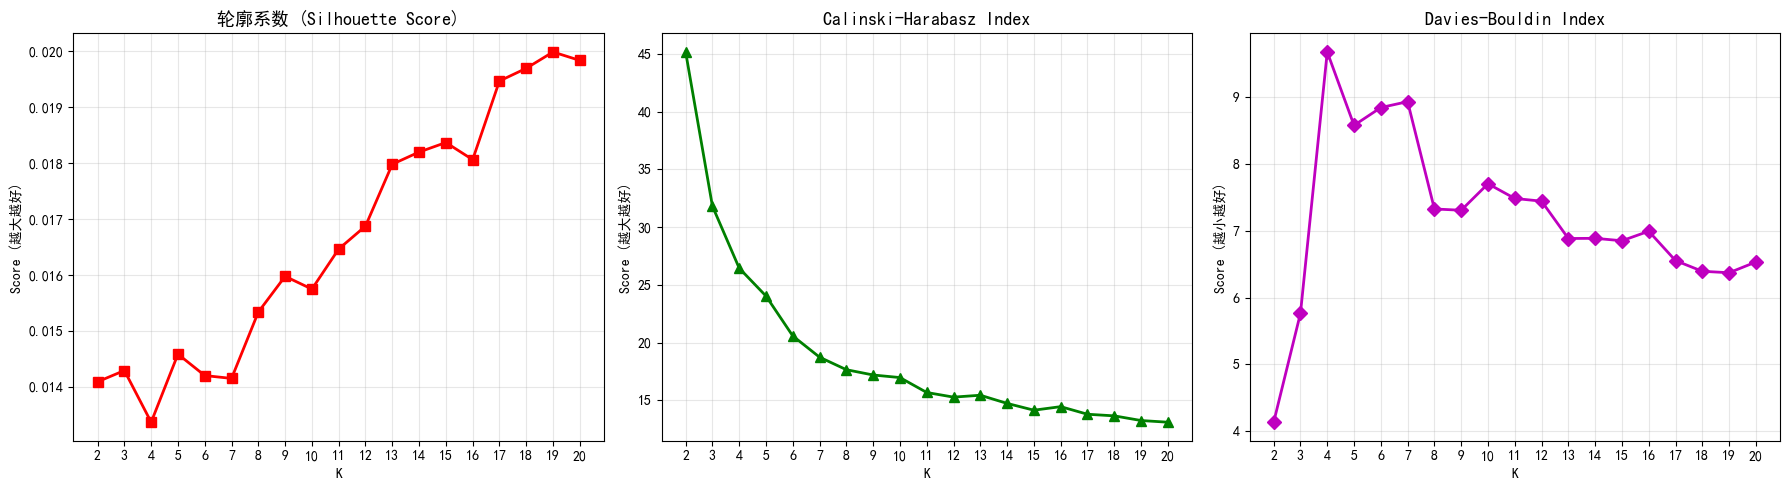


最优 K 建议:
  Silhouette → K=19
  CH Index   → K=2
  DB Index   → K=2


In [37]:
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

sil_scores = []
ch_scores = []
db_scores = []

print("计算各 K 值的聚类评估指标...")
for k in k_range:
    km = KMeans(
        n_clusters=k,
        init="k-means++",
        n_init=KMEANS_N_INIT,
        max_iter=KMEANS_MAX_ITER,
        random_state=KMEANS_RANDOM_STATE,
    )
    labels = km.fit_predict(tfidf_matrix)
    sil = silhouette_score(tfidf_matrix, labels)
    ch = calinski_harabasz_score(tfidf_matrix.toarray(), labels)
    db = davies_bouldin_score(tfidf_matrix.toarray(), labels)
    sil_scores.append(sil)
    ch_scores.append(ch)
    db_scores.append(db)
    print(f"  K={k:2d}  Silhouette={sil:.4f}  CH={ch:.1f}  DB={db:.4f}")

# 绘制三指标对比图
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(k_range, sil_scores, "rs-", linewidth=2, markersize=7)
axes[0].set_title("轮廓系数 (Silhouette Score)", fontsize=13)
axes[0].set_xlabel("K")
axes[0].set_ylabel("Score (越大越好)")
axes[0].set_xticks(k_range)
axes[0].grid(True, alpha=0.3)

axes[1].plot(k_range, ch_scores, "g^-", linewidth=2, markersize=7)
axes[1].set_title("Calinski-Harabasz Index", fontsize=13)
axes[1].set_xlabel("K")
axes[1].set_ylabel("Score (越大越好)")
axes[1].set_xticks(k_range)
axes[1].grid(True, alpha=0.3)

axes[2].plot(k_range, db_scores, "mD-", linewidth=2, markersize=7)
axes[2].set_title("Davies-Bouldin Index", fontsize=13)
axes[2].set_xlabel("K")
axes[2].set_ylabel("Score (越小越好)")
axes[2].set_xticks(k_range)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
fig.savefig(str(FIGURES_DIR / "clustering_metrics.png"), dpi=200)
print(f"\n聚类指标图已保存: {FIGURES_DIR / 'clustering_metrics.png'}")
plt.show()

# 找最优 K
best_k_sil = k_range[np.argmax(sil_scores)]
best_k_ch = k_range[np.argmax(ch_scores)]
best_k_db = k_range[np.argmin(db_scores)]
print(f"\n最优 K 建议:")
print(f"  Silhouette → K={best_k_sil}")
print(f"  CH Index   → K={best_k_ch}")
print(f"  DB Index   → K={best_k_db}")

In [45]:
# ★★★ 根据 Cell 2/3 的结果手动设定 ★★★
BEST_K = 10  # 先用 10 作为默认值，根据实际曲线调整

final_km = KMeans(
    n_clusters=BEST_K,
    init="k-means++",
    n_init=KMEANS_N_INIT,
    max_iter=KMEANS_MAX_ITER,
    random_state=KMEANS_RANDOM_STATE,
)
cluster_labels = final_km.fit_predict(tfidf_matrix)
train_df["cluster"] = cluster_labels

print(f"最终模型: K={BEST_K}")
print(f"WCSS = {final_km.inertia_:.2f}")
print(f"Silhouette = {silhouette_score(tfidf_matrix, cluster_labels):.4f}")
print(f"\n各簇样本数:")
for c in range(BEST_K):
    count = (cluster_labels == c).sum()
    print(f"  簇 {c}: {count} 条")

最终模型: K=10
WCSS = 5817.48
Silhouette = 0.0157

各簇样本数:
  簇 0: 60 条
  簇 1: 199 条
  簇 2: 203 条
  簇 3: 191 条
  簇 4: 83 条
  簇 5: 4055 条
  簇 6: 748 条
  簇 7: 90 条
  簇 8: 357 条
  簇 9: 195 条


In [46]:
print("各簇 Top-10 关键词（按质心向量权重排序）:")
print("=" * 70)

centroids = final_km.cluster_centers_
cluster_keyword_map = {}  # 存储每个簇的关键词，后续用于构建 label mapping

for c in range(BEST_K):
    # 质心向量中权重最高的 10 个特征
    top_idx = centroids[c].argsort()[-10:][::-1]
    top_words = [feature_names[i] for i in top_idx]
    top_weights = [centroids[c][i] for i in top_idx]
    cluster_keyword_map[c] = top_words

    # 统计该簇中原始 category 的分布
    cluster_cats = train_df[train_df["cluster"] == c]["category"].value_counts()
    dominant_cat = cluster_cats.index[0] if len(cluster_cats) > 0 else "未知"

    print(f"\n簇 {c} ({(cluster_labels == c).sum()} 条, 主导类别: {dominant_cat}):")
    for word, weight in zip(top_words, top_weights):
        print(f"  {word:<16s} {weight:.4f}")
    print(f"  类别分布: {dict(cluster_cats)}")

各簇 Top-10 关键词（按质心向量权重排序）:

簇 0 (60 条, 主导类别: 编程技术):
  推荐               0.3075
  推荐 一款            0.0288
  一款               0.0266
  之类               0.0253
  牛腩               0.0218
  片子               0.0187
  最好               0.0182
  类型               0.0174
  好看               0.0171
  好用               0.0162
  类别分布: {'编程技术': 6, '网络': 4, 'DevOps': 3, '移动端': 3, '软件工具': 2, 'Windows系统': 2, '操作系统': 2, '网络配置': 2, '硬件': 1, 'CSS': 1, 'Python': 1, '网络协议': 1, 'React': 1, '编程基础': 1, '数据库': 1}

簇 1 (199 条, 主导类别: 未知):
  回复               0.4609
  回复 哈哈            0.0248
  哈哈               0.0232
  一定               0.0147
  你们               0.0129
  不是               0.0122
  哈哈哈              0.0116
  好吃               0.0101
  亲爱               0.0100
  照片               0.0098
  类别分布: {}

簇 2 (203 条, 主导类别: 网络配置):
  今天               0.2609
  晚上               0.0169
  昨天               0.0158
  你们               0.0141
  中午               0.0136
  还有               0.0125
  小伙伴              0.0123
  早上     

In [47]:
for c in range(BEST_K):
    cluster_df = train_df[train_df["cluster"] == c]
    cats = cluster_df["category"].fillna("").value_counts()
    kw = ", ".join(cluster_keyword_map[c][:5])
    dominant = cats.index[0] if len(cats) > 0 else "空"
    print(f"簇{c} ({(cluster_labels==c).sum()}条) 主导:{dominant} | 关键词: {kw} | 分布:{dict(cats)}")

簇0 (60条) 主导: | 关键词: 推荐, 推荐 一款, 一款, 之类, 牛腩 | 分布:{'': 29, '编程技术': 6, '网络': 4, 'DevOps': 3, '移动端': 3, '软件工具': 2, 'Windows系统': 2, '操作系统': 2, '网络配置': 2, '硬件': 1, 'CSS': 1, 'Python': 1, '网络协议': 1, 'React': 1, '编程基础': 1, '数据库': 1}
簇1 (199条) 主导: | 关键词: 回复, 回复 哈哈, 哈哈, 一定, 你们 | 分布:{'': 199}
簇2 (203条) 主导: | 关键词: 今天, 晚上, 昨天, 你们, 中午 | 分布:{'': 183, '网络配置': 6, 'Windows系统': 4, '前端/浏览器': 3, 'DevOps': 2, '网络安全': 2, '软件工具': 1, '移动端': 1, '后端': 1}
簇3 (191条) 主导: | 关键词: 就是, 还有, 电脑, 人生, 他们 | 分布:{'': 124, '网络': 11, 'Windows系统': 8, '硬件': 7, '编程基础': 6, 'DevOps': 5, '办公软件': 5, '编程技术': 5, '软件工具': 3, '数据库': 2, '后端': 2, '前端/浏览器': 2, '移动端': 2, '网络安全': 2, 'AI/ML': 2, '文件管理': 2, '网络协议': 1, '网络配置': 1, 'JavaScript': 1}
簇4 (83条) 主导: | 关键词: 喜欢, 回复, 我们, 不会, 就是 | 分布:{'': 74, '网络': 4, '编程技术': 2, '移动端': 1, 'Windows系统': 1, '软件工具': 1}
簇5 (4055条) 主导: | 关键词: 哈哈, 你们, 现在, 这里, 还有 | 分布:{'': 3237, '编程技术': 79, '编程基础': 79, '网络': 78, '办公软件': 73, 'Windows系统': 61, 'DevOps': 52, '文件管理': 44, '硬件': 41, '数据库': 37, '移动端': 36, '网络配置': 33, '网络安全':

PCA 散点图已保存: D:\code-hub\ml-service\outputs\figures\kmeans_pca.png


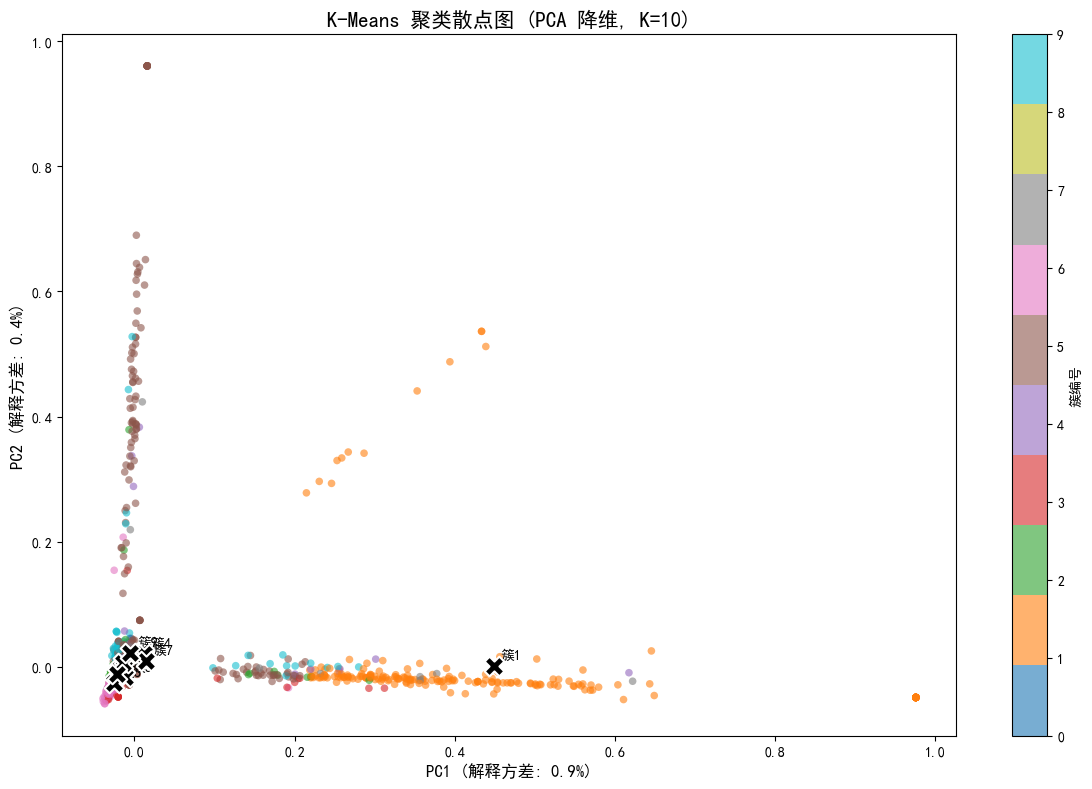

In [48]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
coords_pca = pca.fit_transform(tfidf_matrix.toarray())
centroids_pca = pca.transform(centroids)

fig, ax = plt.subplots(figsize=(12, 8))
scatter = ax.scatter(
    coords_pca[:, 0], coords_pca[:, 1],
    c=cluster_labels, cmap="tab10", alpha=0.6, s=30, edgecolors="none",
)
# 标注质心
for c in range(BEST_K):
    ax.scatter(
        centroids_pca[c, 0], centroids_pca[c, 1],
        c="black", marker="X", s=200, edgecolors="white", linewidths=1.5, zorder=5,
    )
    ax.annotate(
        f"簇{c}", (centroids_pca[c, 0], centroids_pca[c, 1]),
        fontsize=10, fontweight="bold",
        xytext=(5, 5), textcoords="offset points",
    )

ax.set_title(f"K-Means 聚类散点图 (PCA 降维, K={BEST_K})", fontsize=15)
ax.set_xlabel(f"PC1 (解释方差: {pca.explained_variance_ratio_[0]*100:.1f}%)", fontsize=12)
ax.set_ylabel(f"PC2 (解释方差: {pca.explained_variance_ratio_[1]*100:.1f}%)", fontsize=12)
plt.colorbar(scatter, ax=ax, label="簇编号")
plt.tight_layout()

fig.savefig(str(FIGURES_DIR / "kmeans_pca.png"), dpi=200)
print(f"PCA 散点图已保存: {FIGURES_DIR / 'kmeans_pca.png'}")
plt.show()

t-SNE 散点图已保存: D:\code-hub\ml-service\outputs\figures\kmeans_tsne.png


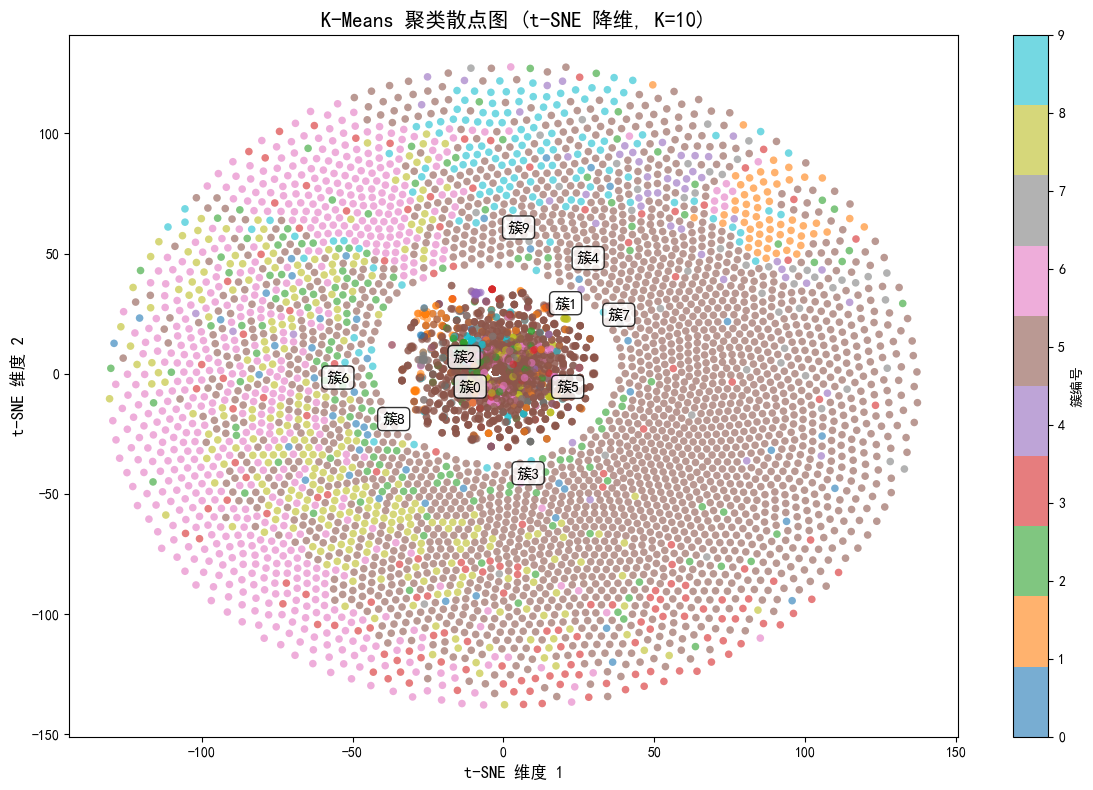

In [49]:
from sklearn.manifold import TSNE

# t-SNE 对数据量敏感，perplexity 不能大于样本数
perp = min(30, len(train_df) - 1)

tsne = TSNE(n_components=2, random_state=42, perplexity=perp, n_iter=1000)
coords_tsne = tsne.fit_transform(tfidf_matrix.toarray())

fig, ax = plt.subplots(figsize=(12, 8))
scatter = ax.scatter(
    coords_tsne[:, 0], coords_tsne[:, 1],
    c=cluster_labels, cmap="tab10", alpha=0.6, s=30, edgecolors="none",
)

# 在每个簇的中心位置标注簇号
for c in range(BEST_K):
    mask = cluster_labels == c
    cx = coords_tsne[mask, 0].mean()
    cy = coords_tsne[mask, 1].mean()
    ax.annotate(
        f"簇{c}", (cx, cy),
        fontsize=11, fontweight="bold",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8),
    )

ax.set_title(f"K-Means 聚类散点图 (t-SNE 降维, K={BEST_K})", fontsize=15)
ax.set_xlabel("t-SNE 维度 1", fontsize=12)
ax.set_ylabel("t-SNE 维度 2", fontsize=12)
plt.colorbar(scatter, ax=ax, label="簇编号")
plt.tight_layout()

fig.savefig(str(FIGURES_DIR / "kmeans_tsne.png"), dpi=200)
print(f"t-SNE 散点图已保存: {FIGURES_DIR / 'kmeans_tsne.png'}")
plt.show()

In [50]:
import json

cluster_labels_map = {
    "0": {"name": "推荐咨询", "tags": ["非技术"], "keywords": ["推荐", "一款", "之类", "好用"]},
    "1": {"name": "灌水回复", "tags": ["非技术"], "keywords": ["回复", "哈哈", "你们"]},
    "2": {"name": "生活日常", "tags": ["非技术"], "keywords": ["今天", "晚上", "昨天", "中午"]},
    "3": {"name": "综合闲聊", "tags": ["非技术"], "keywords": ["就是", "还有", "人生", "他们"]},
    "4": {"name": "情感社交", "tags": ["非技术"], "keywords": ["喜欢", "回复", "我们", "不会"]},
    "5": {"name": "大众闲聊", "tags": ["非技术"], "keywords": ["哈哈", "你们", "现在", "这里"]},
    "6": {"name": "电脑技术", "tags": ["Windows", "软件工具", "硬件", "网络"], "keywords": ["电脑", "下载", "系统", "手机", "安装"]},
    "7": {"name": "地区资讯", "tags": ["非技术"], "keywords": ["北京", "欢迎", "交通"]},
    "8": {"name": "编程开发", "tags": ["AI/ML", "React", "Java", "数据库", "DevOps"], "keywords": ["ai", "数据库", "java", "网络", "移动端"]},
    "9": {"name": "号召互动", "tags": ["非技术"], "keywords": ["我们", "支持", "希望", "一起"]}
}

print("cluster_labels_map:")
print(json.dumps(cluster_labels_map, ensure_ascii=False, indent=2))

cluster_labels_map:
{
  "0": {
    "name": "推荐咨询",
    "tags": [
      "非技术"
    ],
    "keywords": [
      "推荐",
      "一款",
      "之类",
      "好用"
    ]
  },
  "1": {
    "name": "灌水回复",
    "tags": [
      "非技术"
    ],
    "keywords": [
      "回复",
      "哈哈",
      "你们"
    ]
  },
  "2": {
    "name": "生活日常",
    "tags": [
      "非技术"
    ],
    "keywords": [
      "今天",
      "晚上",
      "昨天",
      "中午"
    ]
  },
  "3": {
    "name": "综合闲聊",
    "tags": [
      "非技术"
    ],
    "keywords": [
      "就是",
      "还有",
      "人生",
      "他们"
    ]
  },
  "4": {
    "name": "情感社交",
    "tags": [
      "非技术"
    ],
    "keywords": [
      "喜欢",
      "回复",
      "我们",
      "不会"
    ]
  },
  "5": {
    "name": "大众闲聊",
    "tags": [
      "非技术"
    ],
    "keywords": [
      "哈哈",
      "你们",
      "现在",
      "这里"
    ]
  },
  "6": {
    "name": "电脑技术",
    "tags": [
      "Windows",
      "软件工具",
      "硬件",
      "网络"
    ],
    "keywords": [
      "电脑",
      "下载",
      "系统",
    

In [51]:
os.makedirs(str(MODELS_DIR), exist_ok=True)

# 保存 K-Means 模型
joblib.dump(final_km, str(KMEANS_MODEL_FILE))
print(f"K-Means 模型已保存: {KMEANS_MODEL_FILE}")
print(f"  文件大小: {os.path.getsize(str(KMEANS_MODEL_FILE)) / 1024:.1f} KB")

# 保存 cluster_labels.json
with open(str(CLUSTER_LABELS_FILE), "w", encoding="utf-8") as f:
    json.dump(cluster_labels_map, f, ensure_ascii=False, indent=2)
print(f"标签映射已保存: {CLUSTER_LABELS_FILE}")

# 验证
loaded_km = joblib.load(str(KMEANS_MODEL_FILE))
test_vec = vectorizer.transform(["React hooks 状态管理 组件"])
pred = loaded_km.predict(test_vec)
pred_cluster = str(pred[0])
with open(str(CLUSTER_LABELS_FILE), "r", encoding="utf-8") as f:
    loaded_labels = json.load(f)
print(f"\n验证: 'React hooks 状态管理 组件' → 簇 {pred_cluster} → {loaded_labels[pred_cluster]}")

K-Means 模型已保存: D:\code-hub\ml-service\models\kmeans_model.pkl
  文件大小: 415.5 KB
标签映射已保存: D:\code-hub\ml-service\models\cluster_labels.json

验证: 'React hooks 状态管理 组件' → 簇 8 → {'name': '编程开发', 'tags': ['AI/ML', 'React', 'Java', '数据库', 'DevOps'], 'keywords': ['ai', '数据库', 'java', '网络', '移动端']}
